<a href="https://colab.research.google.com/github/rafaelschaves/gele7317-proc-sin/blob/master/non_stationary_signal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### MATLAB to Python Conversion

This section translates the provided MATLAB code into Python. Key changes include:
-   Using `numpy` for array creation (`np.arange`, `np.zeros_like`).
-   Adjusting for 0-based indexing in Python slicing.
-   Using `np.sin` for the sine function and `**2` for element-wise squaring.
-   `fix(x)` in MATLAB is equivalent to `int(x)` or `np.trunc(x)` for integer truncation towards zero.

In [2]:
import numpy as np

# MATLAB code:
# N = 2000; t = [0:N];
# x = zeros(size(t));

N = 2000
t = np.arange(N + 1) # Python: 0 to N inclusive
x = np.zeros_like(t, dtype=np.float64) # Initialize x as float to allow for sin wave additions

# MATLAB code:
# pos_sin = [0 600 1080 1380 1680 2000];
# T_sin = [100 40 20 10 5];
# for i = 1:5,
#   m = 1 + pos_sin(i); n = pos_sin(i+1);
#   x(m:n) = sin(2*pi*t(1:n-m+1)/T_sin(i));
# end;

pos_sin = np.array([0, 600, 1080, 1380, 1680, 2000])
T_sin = np.array([100, 40, 20, 10, 5])

for i in range(5):
    # Python uses 0-based indexing. If MATLAB m,n are 1-based, then
    # x(m:n) in MATLAB is x[m-1:n] in Python.
    # The 't' in sin(2*pi*t(...)) refers to a sequence of numbers 1, 2, ..., length_of_segment

    start_idx_py = pos_sin[i]
    end_idx_py = pos_sin[i+1] # This is exclusive in Python slice

    segment_length = end_idx_py - start_idx_py
    t_segment_values = np.arange(1, segment_length + 1) # Generates 1, 2, ..., segment_length

    x[start_idx_py : end_idx_py] = np.sin(2 * np.pi * t_segment_values / T_sin[i])

# MATLAB code:
# amp_imp = [3 -2 2 2.5 -2.5];
# pos_imp = [200 372 1324 1343 1802];
# T_imp = [5 25 5 5 5];
# for i = 1:5,
#   m = 1 + pos_imp(i); n = 1 + pos_imp(i) + fix(T_imp(i)/2);
#   x(m:n) = x(m:n) + amp_imp(i)*sin(2*pi*t(1:n-m+1)/T_imp(i)).^2;
# end;

amp_imp = np.array([3, -2, 2, 2.5, -2.5])
pos_imp = np.array([200, 372, 1324, 1343, 1802])
T_imp = np.array([5, 25, 5, 5, 5])

for i in range(5):
    start_idx_py = pos_imp[i]
    # MATLAB fix(x) truncates towards zero, equivalent to int() for positive numbers
    relative_end_offset = int(T_imp[i] / 2)
    end_idx_py = pos_imp[i] + relative_end_offset # This is the last inclusive index in Python

    segment_length = end_idx_py - start_idx_py + 1
    t_segment_values = np.arange(1, segment_length + 1) # Generates 1, 2, ..., segment_length

    x[start_idx_py : end_idx_py + 1] += amp_imp[i] * (np.sin(2 * np.pi * t_segment_values / T_imp[i]))**2

# You can display or plot 'x' now to verify the results
# For example, to display a portion of x:
print(x[:100])

[ 6.27905195e-02  1.25333234e-01  1.87381315e-01  2.48689887e-01
  3.09016994e-01  3.68124553e-01  4.25779292e-01  4.81753674e-01
  5.35826795e-01  5.87785252e-01  6.37423990e-01  6.84547106e-01
  7.28968627e-01  7.70513243e-01  8.09016994e-01  8.44327926e-01
  8.76306680e-01  9.04827052e-01  9.29776486e-01  9.51056516e-01
  9.68583161e-01  9.82287251e-01  9.92114701e-01  9.98026728e-01
  1.00000000e+00  9.98026728e-01  9.92114701e-01  9.82287251e-01
  9.68583161e-01  9.51056516e-01  9.29776486e-01  9.04827052e-01
  8.76306680e-01  8.44327926e-01  8.09016994e-01  7.70513243e-01
  7.28968627e-01  6.84547106e-01  6.37423990e-01  5.87785252e-01
  5.35826795e-01  4.81753674e-01  4.25779292e-01  3.68124553e-01
  3.09016994e-01  2.48689887e-01  1.87381315e-01  1.25333234e-01
  6.27905195e-02  1.22464680e-16 -6.27905195e-02 -1.25333234e-01
 -1.87381315e-01 -2.48689887e-01 -3.09016994e-01 -3.68124553e-01
 -4.25779292e-01 -4.81753674e-01 -5.35826795e-01 -5.87785252e-01
 -6.37423990e-01 -6.84547

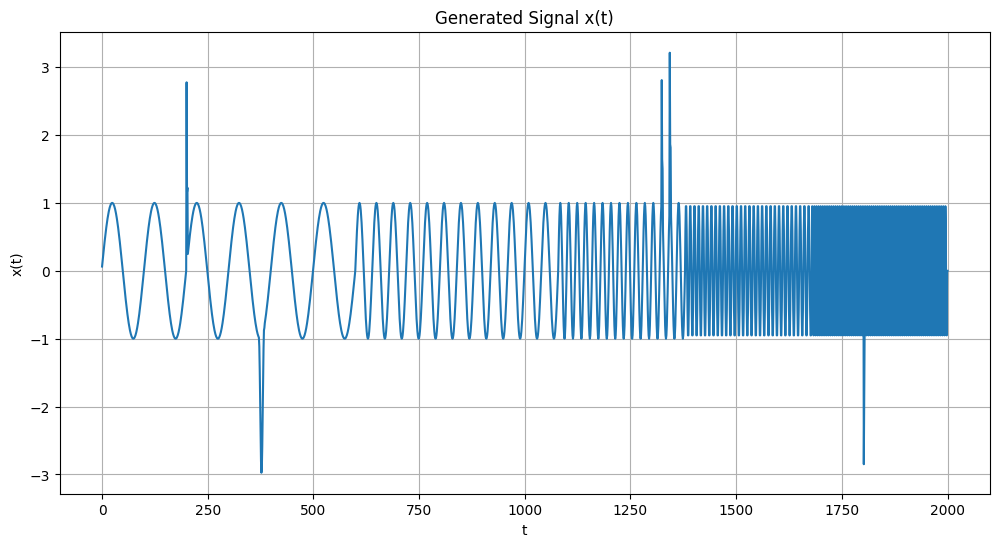

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(t, x)
plt.title('Generated Signal x(t)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True)
plt.show()